In [1]:
!pip install tensorflow
!pip install keras
!pip install imblearn
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tensorflow-addons

  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)
  Attempting uninstall: keras
    Found existing installation: keras 3.3.3
    Uninstalling keras-3.3.3:
      Successfully uninstalled keras-3.3.3
^C
ERROR: Operation cancelled by user


In [40]:
! pip install -q kaggle

/home/abm/miniconda3/envs/alz/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [41]:
! mkdir ~/.kaggle

! cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/home/abm/.kaggle’: File exists


In [42]:
 ! chmod 600 ~/.kaggle/kaggle.json

In [43]:
! kaggle datasets list

ref                                                             title                                              size  lastUpdated          downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
rahulvyasm/netflix-movies-and-tv-shows                          Netflix Movies and TV Shows                         1MB  2024-04-10 09:48:38          12300        258  1.0              
anandshaw2001/airlines-booking-csv                              Airlines_Booking.csv                              414KB  2024-04-20 17:38:50           2153         33  1.0              
sahirmaharajj/school-student-daily-attendance                   School Student Daily Attendance                     2MB  2024-04-29 19:29:56           1389         32  1.0              
jaidalmotra/pokemon-dataset                                     Pokemo

In [44]:
!kaggle datasets download -d shahidzikria/alz-dataset

Dataset URL: https://www.kaggle.com/datasets/shahidzikria/alz-dataset
License(s): unknown
alz-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [45]:
!unzip alz-dataset.zip

Archive:  alz-dataset.zip
replace dataset/MildDemented/26 (19).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


### <font color=orange> Importing Libraries </font>

In [1]:
import numpy as np
import random

#   Plotting
import seaborn as sns
import matplotlib.pyplot as plt


#   DataGenerator to read images and rescale images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import tensorflow as tf
import tensorflow_addons as tfa

#   count each class samples
from collections import Counter

#   callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau

#   evaluate precison recall and f1-score of each class of model
from sklearn.metrics import classification_report
#   Show performance of a classification model
from sklearn.metrics import confusion_matrix

#   Different layers
from keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Convolution2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import ReLU
from tensorflow.keras.layers import Softmax

# split dataset to train, validation and test set
from sklearn.model_selection import train_test_split

#   callbacks
from keras import callbacks

#   SMOTETomek from imblance library
from imblearn.combine import SMOTETomek

#   Optimizer
from tensorflow.keras.optimizers import SGD

from sklearn.metrics import roc_curve, auc
from itertools import cycle

2024-05-11 01:52:30.536316: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-11 01:52:30.577983: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-11 01:52:30.578017: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-11 01:52:30.579197: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-11 01:52:30.585210: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-11 01:52:30.585770: I tensorflow/core/platform/cpu_feature_guard.cc:1

### <font color=orange> Define directory of dataset & Classes names </font>

In [2]:
## Set Path Here before running the code
WORKING_DIRECTORY =  "./dataset/"

##  Name of classes 
CLASSES = ['Mild-Demented',
           'Moderate-Demented',
           'Non-Demented',
           'VeryMild-Demented']

### <font color=orange> Load Images, Rescale Images, and seperate from data generator & Label One Hot encoding </font>

In [3]:
X, y = [], []

## Images rescaling
datagen = ImageDataGenerator(rescale=1.0/255.0)

#   Load images by resizing and shuffling randomly
train_dataset = datagen.flow_from_directory(WORKING_DIRECTORY, target_size=(176, 208),batch_size=6400, shuffle=True)

### Seperate Dataset from  Data Genrator
X, y = train_dataset.next()

Found 6400 images belonging to 4 classes.


In [4]:
samples_before = len(X)
print("Images shape :\t", X.shape)
print("Labels shape :\t", y.shape)

Images shape :	 (6400, 176, 208, 3)
Labels shape :	 (6400, 4)


In [5]:
#   Number of samples in classes 
print("Number of samples in each class:\t", sorted(Counter(np.argmax(y, axis=1)).items()))

#   class labels as per indices
print("Classes Names according to index:\t", train_dataset.class_indices)

Number of samples in each class:	 [(0, 896), (1, 64), (2, 3200), (3, 2240)]
Classes Names according to index:	 {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


### <font color=orange> Show some random samples from the origional dataset </font>

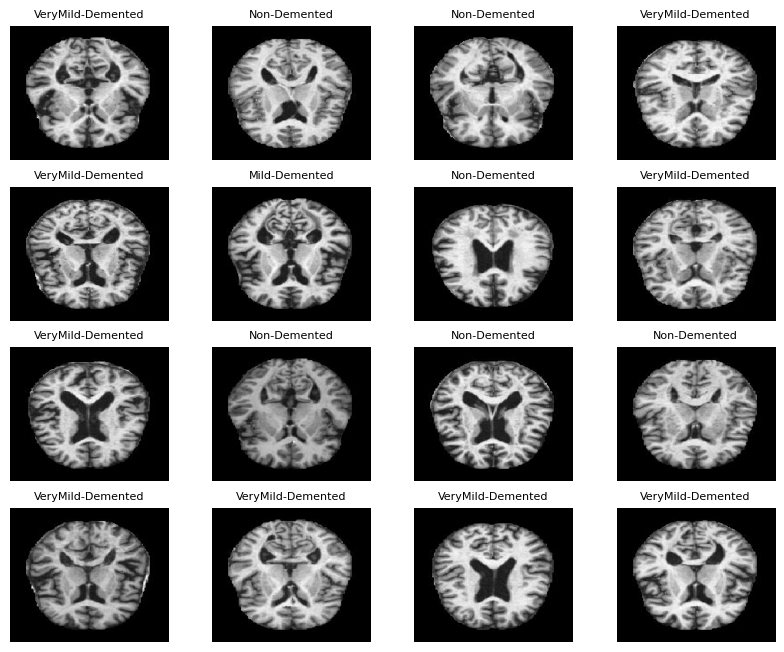

In [6]:
#   show some samples from the dataset randomly
fig = plt.figure(figsize=(10,8))

rows = 4
columns = 4

for i in range(rows * columns):
    fig.add_subplot(rows, columns, i+1)
    num = random.randint(0, len(X)-1 )
    plt.imshow(X[num])
    plt.axis('off')
    plt.title(CLASSES[(np.argmax(y[num]))], fontsize=8)
plt.axis('off')
plt.show()

### <font color=orange> Apply SMOTETomek Algorithm to balance the dataset </font>

In [7]:
#   reshaping the images to 1D
X = X.reshape(-1, 176 * 208 * 3)

#   Oversampling method to remove imbalance class problem
X, y = SMOTETomek().fit_resample(X, y)

#   reshape images to images size of 208, 176, 3
X = X.reshape(-1, 176, 208, 3)

samples_after = len(X)
print("Number of samples after SMOTETomek :\t", sorted(Counter(np.argmax(y, axis=1)).items()))

Number of samples after SMOTETomek :	 [(0, 3200), (1, 3200), (2, 3200), (3, 3200)]


### <font color=orange> Show some random samples from the Generated dataset </font>

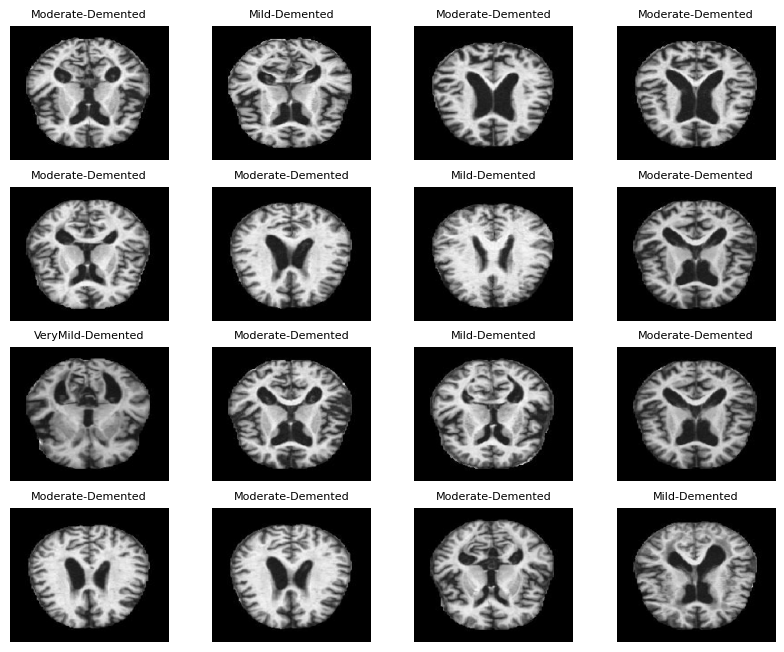

In [8]:
fig = plt.figure(figsize=(10,8))

rows = 4
columns = 4

for i in range(rows * columns):
    fig.add_subplot(rows, columns, i+1)
    num = random.randint(samples_before, samples_after - 1 )
    plt.imshow(X[num])
    plt.axis('off')
    plt.title(CLASSES[(np.argmax(y[num]))], fontsize=8)
plt.axis('off')
plt.show()

### <font color=orange> Splitting dataset for Training, Validation & Testing </font>

In [9]:
#   20% split to validation and 80% split to train set
X_train, x_val, y_train, y_val = train_test_split(X,y, test_size = 0.2)

#   20% split to test from 80% of train and 60% remains in train set
X_train, x_test, y_train, y_test = train_test_split(X_train,y_train, test_size = 0.2)

# Number of samples after train test split
print("Number of samples after splitting into Training, validation & test set\n")

print("Train     \t",sorted(Counter(np.argmax(y_train, axis=1)).items()))
print("Validation\t",sorted(Counter(np.argmax(y_val, axis=1)).items()))
print("Test      \t",sorted(Counter(np.argmax(y_test, axis=1)).items()))

Number of samples after splitting into Training, validation & test set

Train     	 [(0, 2071), (1, 2031), (2, 2061), (3, 2029)]
Validation	 [(0, 607), (1, 658), (2, 628), (3, 667)]
Test      	 [(0, 522), (1, 511), (2, 511), (3, 504)]


In [10]:
#   to free memeory we don't need this one as we split our data
del X, y

### <font color=orange> Model Architecture </font>

In [11]:
#from keras import GlorotUniformV2
from keras.initializers import GlorotUniform
init = GlorotUniform

model = Sequential()

model.add(Input(shape=(176, 208, 3)))

model.add(Convolution2D(16, 5, kernel_initializer=init))
model.add(ReLU())
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Convolution2D(32, 5, kernel_initializer=init))
model.add(ReLU())
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Convolution2D(64, 5, kernel_initializer=init))
model.add(ReLU())
model.add(AveragePooling2D(pool_size=(2,2)))

model.add(Convolution2D(128, 5, kernel_initializer=init))
model.add(ReLU())
model.add(AveragePooling2D(pool_size=(2,2)))


model.add(Dropout(0.01))

model.add(Flatten())

model.add(Dense(256, kernel_initializer=init))
model.add(ReLU())
model.add(Dropout(0.03))

model.add(Dense(4, kernel_initializer=init))
model.add(Softmax())

model.summary()

2024-05-11 01:59:16.137949: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2024-05-11 01:59:16.138220: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: abm-Precision-7720
2024-05-11 01:59:16.138235: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: abm-Precision-7720
2024-05-11 01:59:16.138415: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 535.171.4
2024-05-11 01:59:16.138455: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 535.171.4
2024-05-11 01:59:16.138466: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:241] kernel version seems to match DSO: 535.171.4


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 172, 204, 16)      1216      
                                                                 
 re_lu (ReLU)                (None, 172, 204, 16)      0         
                                                                 
 average_pooling2d (Average  (None, 86, 102, 16)       0         
 Pooling2D)                                                      
                                                                 
 conv2d_1 (Conv2D)           (None, 82, 98, 32)        12832     
                                                                 
 re_lu_1 (ReLU)              (None, 82, 98, 32)        0         
                                                                 
 average_pooling2d_1 (Avera  (None, 41, 49, 32)        0         
 gePooling2D)                                           

### <font color=orange> Compiling the Model </font>

In [12]:
### Model Compilation
model.compile(
    optimizer=SGD(learning_rate=0.01), 
    loss = tf.keras.losses.CategoricalCrossentropy(name='loss'), 
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='acc'), 
        tf.keras.metrics.AUC(name='auc'),
        tfa.metrics.F1Score(num_classes=4),
        tf.metrics.Precision(name="precision"),
        tf.metrics.Recall(name="recall") ])


### <font color=orange> Defining CALLBACKS to reduce Learning Rate </font>

In [13]:
# callbacks used in model to perform well
rop_callback = ReduceLROnPlateau(monitor="val_loss", patience=2)

CALLBACKS = [rop_callback]

### <font color=orange> Training of the Model </font>

In [14]:
#   declare to run on small gpu create batch sizes of images
valAug = ImageDataGenerator()

#   defining batch size
batch_size = 8

history = model.fit(valAug.flow(X_train, y_train, batch_size=batch_size, shuffle = True),
steps_per_epoch=len(X_train) // batch_size,
validation_data=valAug.flow(x_val, y_val, batch_size=batch_size, shuffle = True),
validation_steps=len(x_test) // batch_size,
epochs= 15,
batch_size=batch_size,
callbacks = CALLBACKS
)

Epoch 1/15
1024/1024 [==============================] - 153s 147ms/step - loss: 1.2294 - acc: 0.4093 - auc: 0.6874 - f1_score: 0.4004 - precision: 0.6937 - recall: 0.1366 - val_loss: 0.8378 - val_acc: 0.6030 - val_auc: 0.8738 - val_f1_score: 0.5479 - val_precision: 0.7231 - val_recall: 0.4756 - lr: 0.0100
Epoch 2/15
1024/1024 [==============================] - 148s 144ms/step - loss: 0.7272 - acc: 0.6569 - auc: 0.8996 - f1_score: 0.6480 - precision: 0.7532 - recall: 0.5353 - val_loss: 0.6393 - val_acc: 0.6685 - val_auc: 0.9188 - val_f1_score: 0.6622 - val_precision: 0.8349 - val_recall: 0.5186 - lr: 0.0100
Epoch 3/15
1024/1024 [==============================] - 148s 145ms/step - loss: 0.6059 - acc: 0.7223 - auc: 0.9307 - f1_score: 0.7177 - precision: 0.7776 - recall: 0.6353 - val_loss: 0.6145 - val_acc: 0.7158 - val_auc: 0.9306 - val_f1_score: 0.7008 - val_precision: 0.7574 - val_recall: 0.6602 - lr: 0.0100
Epoch 4/15
1024/1024 [==============================] - 151s 147ms/step - loss:

### <font color=orange> Evaluation of Model with the Test data </font>

In [15]:
### Evaluate Model
test_scores = model.evaluate(x_test, y_test, batch_size = 32)


print("\n\nTesting Loss : \t\t {0:0.6f}".format(test_scores[0] ))
print("Testing Accuracy : \t {0:0.6f} %".format(test_scores[1] * 100))
print("Testing AC : \t\t {0:0.6f} %".format(test_scores[2] * 100))
print("Testing F1-Score : \t {0:0.6f} %".format(((test_scores[3][0] + test_scores[3][1] + test_scores[3][2] + test_scores[3][3])/4) * 100))
print("Testing Precision : \t {0:0.6f} %".format(test_scores[4] * 100))
print("Testing Recall : \t {0:0.6f} %".format(test_scores[5] * 100))

64/64 [==============================] - 8s 130ms/step - loss: 0.0387 - acc: 0.9883 - auc: 0.9992 - f1_score: 0.9882 - precision: 0.9888 - recall: 0.9883


Testing Loss : 		 0.038703
Testing Accuracy : 	 98.828125 %
Testing AC : 		 99.916786 %
Testing F1-Score : 	 98.819387 %
Testing Precision : 	 98.876405 %
Testing Recall : 	 98.828125 %


In [48]:
test_scores = model.evaluate(x_test, y_test, batch_size=32)
print("\n\nTesting Loss : \t\t {0:0.6f}".format(test_scores[0]))
print("Testing Accuracy : \t {0:0.6f} %".format(test_scores[1] * 100))
# Check and include additional metrics only if they are defined during model compilation
if len(test_scores) > 2:
    print("Testing Precision : \t {0:0.6f} %".format(test_scores[2] * 100))
    print("Testing Recall : \t {0:0.6f} %".format(test_scores[3] * 100))
    # Calculate F1-Score if Precision and Recall are available
    precision = test_scores[2]
    recall = test_scores[3]
    if precision + recall != 0:  # Avoid division by zero
        f1_score = 2 * (precision * recall) / (precision + recall)
        print("Testing F1-Score : \t {0:0.6f} %".format(f1_score * 100))

64/64 [==============================] - 8s 118ms/step - loss: 0.0372 - acc: 0.9873 - auc: 0.9988 - f1_score: 0.9877 - precision: 0.9873 - recall: 0.9873


Testing Loss : 		 0.037181
Testing Accuracy : 	 98.730469 %
Testing Precision : 	 99.880713 %


TypeError: unsupported format string passed to numpy.ndarray.__format__

### <font color=orange> Model Training graphs </font>
- Accuracy
- Loss
- AUC
- Precision
- Recall
- F1-Score

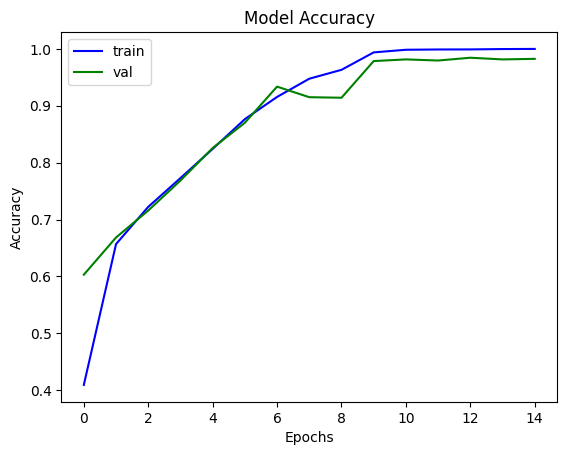

In [16]:
plt.plot(history.history['acc'], 'b')
plt.plot(history.history['val_acc'], 'g')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["train", "val"])
plt.show()

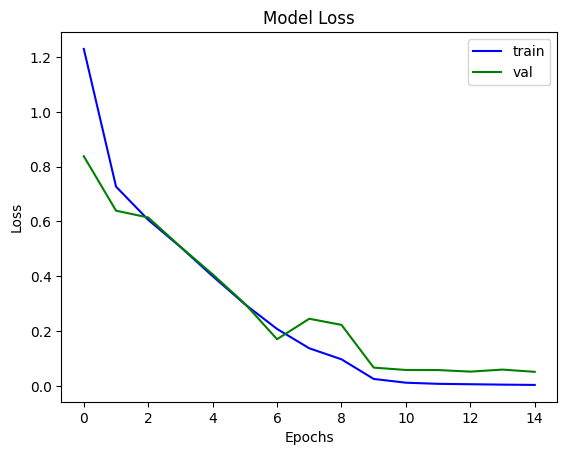

In [17]:
plt.plot(history.history['loss'], 'b')
plt.plot(history.history['val_loss'], 'g')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["train", "val"])
plt.show()

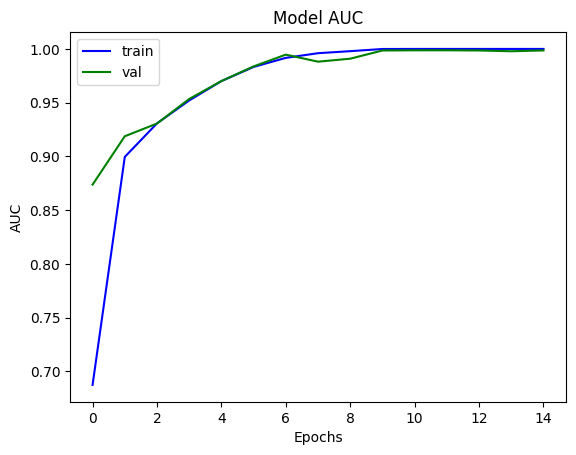

In [18]:
plt.plot(history.history['auc'], 'b')
plt.plot(history.history['val_auc'], 'g')
plt.title("Model AUC")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend(["train", "val"])
plt.show()

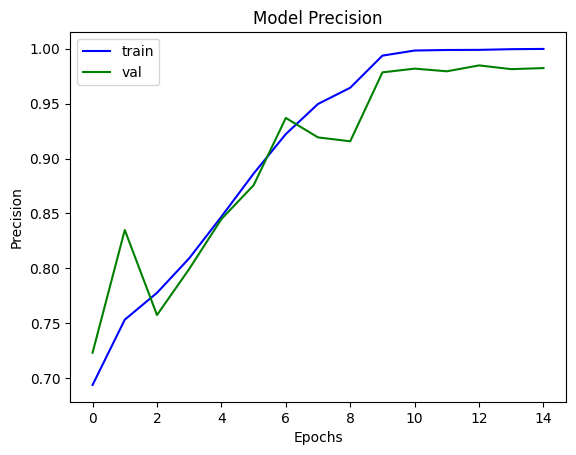

In [19]:
plt.plot(history.history['precision'], 'b')
plt.plot(history.history['val_precision'], 'g')
plt.title("Model Precision")
plt.xlabel("Epochs")
plt.ylabel("Precision")
plt.legend(["train", "val"])
plt.show()

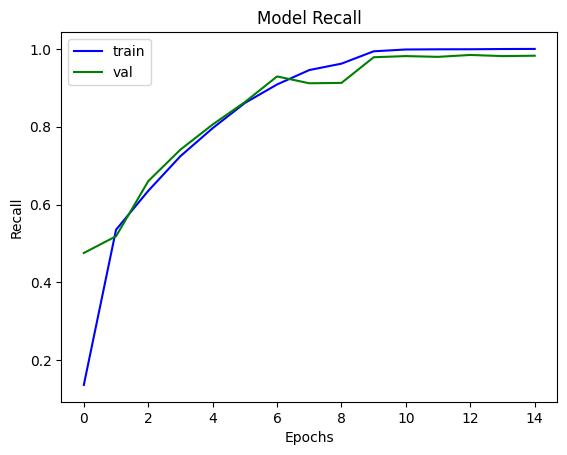

In [20]:
plt.plot(history.history['recall'], 'b')
plt.plot(history.history['val_recall'], 'g')
plt.title("Model Recall")
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.legend(["train", "val"])
plt.show()

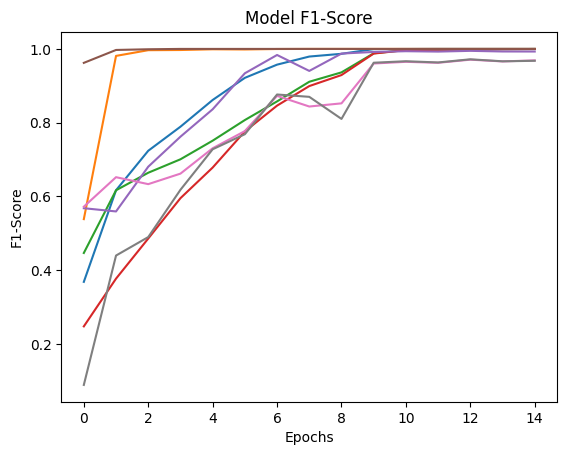

In [21]:
plt.plot(history.history['f1_score'])
plt.plot(history.history['val_f1_score'])
plt.title("Model F1-Score")
plt.xlabel("Epochs")
plt.ylabel("F1-Score")
plt.show()

### <font color=orange> Test set Evaluation </font>
- Classification Report
- Confusion Matrix
- ROC Curve
- Extension ROC Multiclass

In [22]:
pred_labels = model.predict(x_test, batch_size=32)

def roundoff(arr):
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)

print(classification_report(y_test, pred_labels, target_names=CLASSES))


64/64 [==============================] - 8s 127ms/step
                   precision    recall  f1-score   support

    Mild-Demented       0.99      1.00      1.00       522
Moderate-Demented       1.00      1.00      1.00       511
     Non-Demented       0.99      0.97      0.98       511
VeryMild-Demented       0.97      0.99      0.98       504

        micro avg       0.99      0.99      0.99      2048
        macro avg       0.99      0.99      0.99      2048
     weighted avg       0.99      0.99      0.99      2048
      samples avg       0.99      0.99      0.99      2048



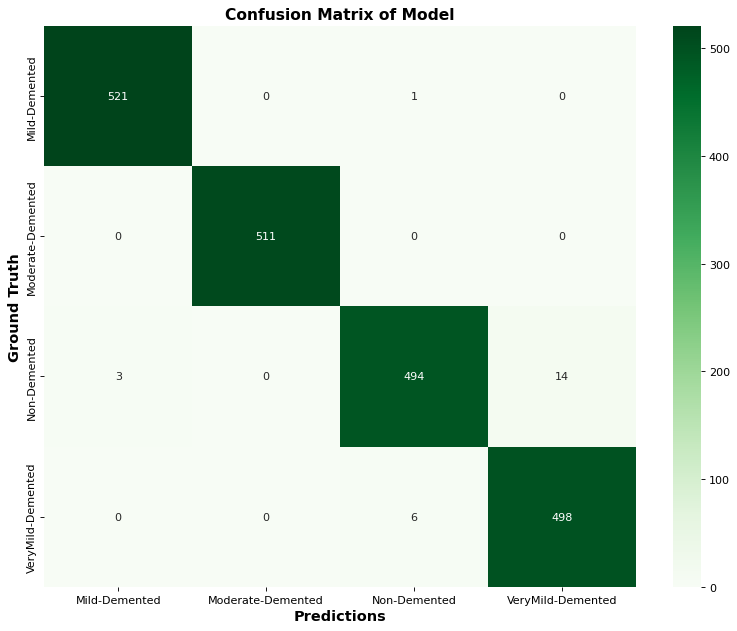

In [23]:
pred_ls = np.argmax(pred_labels, axis=1)
test_ls = np.argmax(y_test, axis=1)

conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(10, 8), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels= CLASSES, yticklabels=CLASSES)

plt.title('Confusion Matrix of Model', fontweight='bold', fontsize=14.0)
plt.xlabel('Predictions', fontweight='bold', fontsize=13)
plt.ylabel('Ground Truth', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show(ax)

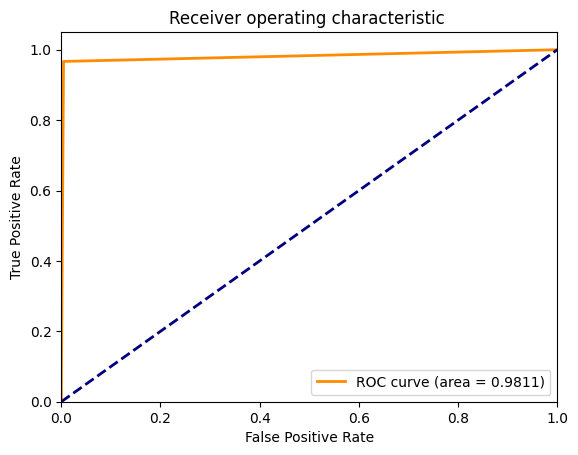

In [24]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], pred_labels[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), pred_labels.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 2
plt.plot(
    fpr[2],
    tpr[2],
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.4f)" % roc_auc[2])

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic ")
plt.legend(loc="lower right")
plt.show()

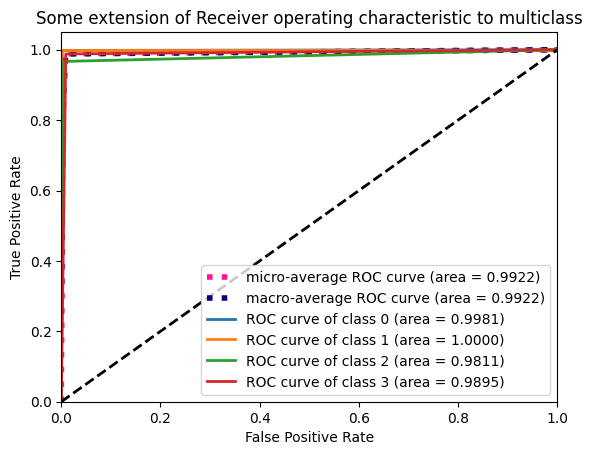

In [25]:
n_classes = 4
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.4f})".format(roc_auc["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="macro-average ROC curve (area = {0:0.4f})".format(roc_auc["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=lw,
        label="ROC curve of class {0} (area = {1:0.4f})".format(i, roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()

### <font color=orange> Saving Model for Future Use </font>

In [26]:
#    To save the model in the current directory
model.save("./model1.h5")

/home/abm/miniconda3/envs/alz/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [31]:
model.save('my_model.keras')

In [49]:
import numpy as np
import cv2
from keras.models import load_model

model = load_model('model.h5')

input_image = cv2.imread('2.jpg')
input_image = cv2.resize(input_image, (208, 176)) 
input_image = input_image / 255.0  

input_image = np.expand_dims(input_image, axis=0)

predictions = model.predict(input_image)

predicted_class = np.argmax(predictions)
class_labels = ['Mild-Demented', 'Moderate-Demented', 'Non-Demented', 'VeryMild-Demented']

predicted_label = class_labels[predicted_class]
print(predicted_label)


1/1 [==============================] - 0s 106ms/step
Moderate-Demented


In [48]:
import numpy as np
import cv2
from keras.models import load_model

# Load the saved Keras model
model = load_model('model.h5')

# Load and preprocess the input image
input_image = cv2.imread('26.jpg')
input_image = cv2.resize(input_image, (208, 176))  # Assuming input size expected by the model is 224x224
input_image = input_image / 255.0  # Normalize pixel values

# Add a batch dimension
input_image = np.expand_dims(input_image, axis=0)

# Predict class probabilities
predictions = model.predict(input_image)

# Get the predicted class
predicted_class = np.argmax(predictions)

# Define class labels (replace with your actual class labels)
class_labels = ['Mild-Demented', 'Moderate-Demented', 'Non-Demented', 'VeryMild-Demented']

# Get the class label corresponding to the predicted class
predicted_label = class_labels[predicted_class]
print(predicted_label)



1/1 [==============================] - 0s 92ms/step
VeryMild-Demented
